In [5]:
# Story 1: Library Imports
%pip install seaborn pandas numpy matplotlib scikit-learn imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -- NEW IMPORTS FOR STEP 2 & 3 --
# Preprocessing & Encoding
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Modeling
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Handling Imbalanced Data (Optional but recommended for Credit Datasets)
from imblearn.over_sampling import SMOTE 

# Set visual preferences for seaborn
sns.set_theme(style="whitegrid")

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Story 2: Data Loading, Aggregation, and Initial Exploration

# 1. Load the new datasets
# Ensure the file paths point to where you saved the application and credit records
import pandas as pd

app_df = pd.read_csv(r'..\creditcard_csv\application_record.csv')
credit_df = pd.read_csv(r'..\creditcard_csv\credit_record.csv')

# 2. Aggregate the Credit History to create the Target Variable
# In this dataset, STATUS translates to: 
# C = Paid off, X = No loan, 0 = 1-29 days overdue, 1 = 30-59 days, 2 = 60-89 days...
# Let's define a "Bad" client as anyone who hits 60+ days past due ('2', '3', '4', '5')
credit_df['Is_High_Risk'] = credit_df['STATUS'].apply(lambda x: 1 if x in ['2', '3', '4', '5'] else 0)

# If an applicant EVER hits High Risk across their month-to-month history, flag their ID as 1
target_df = credit_df.groupby('ID')['Is_High_Risk'].max().reset_index()

# 3. Merge the Target back into the Application Features
# We use an 'inner' join to guarantee we only keep applicants who have BOTH demographic data and a credit history
df = pd.merge(app_df, target_df, on='ID', how='inner')

# 4. Initial Exploration
# Display the first 5 rows to verify the merge and inspect the new multidimensional feature space
display(df.head())

# Output column names, non-null counts, and data types to prepare for encoding
df.info()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,Is_High_Risk
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   CODE_GENDER          36457 non-null  object 
 2   FLAG_OWN_CAR         36457 non-null  object 
 3   FLAG_OWN_REALTY      36457 non-null  object 
 4   CNT_CHILDREN         36457 non-null  int64  
 5   AMT_INCOME_TOTAL     36457 non-null  float64
 6   NAME_INCOME_TYPE     36457 non-null  object 
 7   NAME_EDUCATION_TYPE  36457 non-null  object 
 8   NAME_FAMILY_STATUS   36457 non-null  object 
 9   NAME_HOUSING_TYPE    36457 non-null  object 
 10  DAYS_BIRTH           36457 non-null  int64  
 11  DAYS_EMPLOYED        36457 non-null  int64  
 12  FLAG_MOBIL           36457 non-null  int64  
 13  FLAG_WORK_PHONE      36457 non-null  int64  
 14  FLAG_PHONE           36457 non-null  int64  
 15  FLAG_EMAIL           36457 non-null 

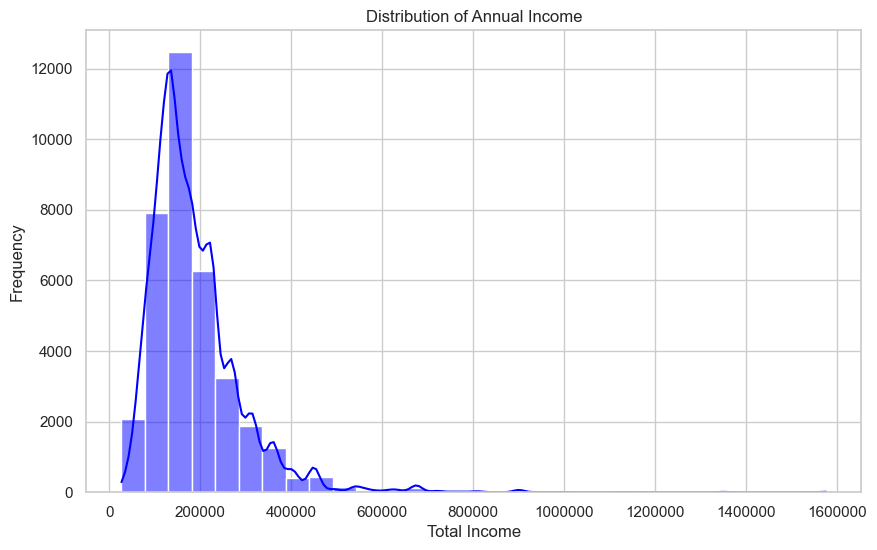

C:\Users\ch-ka\AppData\Local\Temp\ipykernel_17752\856756888.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='NAME_EDUCATION_TYPE', data=df, palette='viridis')


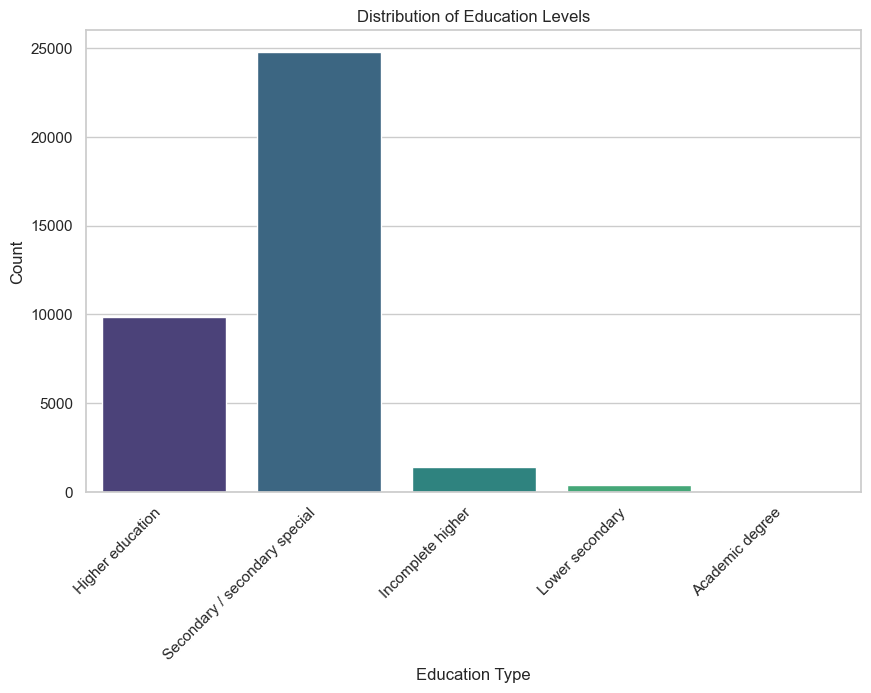

C:\Users\ch-ka\AppData\Local\Temp\ipykernel_17752\856756888.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Is_High_Risk', data=df, palette='Set2')


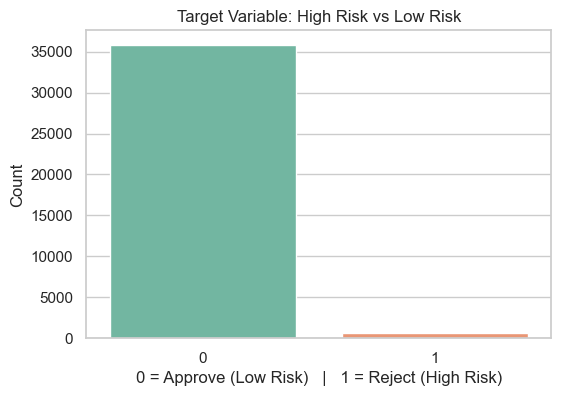

In [6]:
# Story 3: Univariate Analysis

# 1. Distribution of a numerical variable (Annual Income)
plt.figure(figsize=(10, 6))
# Updated from 'Amount' to the correct SmartBridge column: 'AMT_INCOME_TOTAL'
sns.histplot(df['AMT_INCOME_TOTAL'], kde=True, color='blue', bins=30)
plt.title('Distribution of Annual Income')
plt.xlabel('Total Income')
plt.ylabel('Frequency')
# Formatting the x-axis so the large income numbers don't overlap
plt.ticklabel_format(style='plain', axis='x') 
plt.show()

# 2. Count of a categorical variable (Education Level)
plt.figure(figsize=(10, 6))
# Updated from 'Class' to the correct SmartBridge column: 'NAME_EDUCATION_TYPE'
sns.countplot(x='NAME_EDUCATION_TYPE', data=df, palette='viridis')
plt.title('Distribution of Education Levels')
plt.xlabel('Education Type')
plt.ylabel('Count')
# Added ha='right' to align the angled text properly
plt.xticks(rotation=45, ha='right') 
plt.show()

# 3. Distribution of the Target Variable (Checking for Class Imbalance)
plt.figure(figsize=(6, 4))
sns.countplot(x='Is_High_Risk', data=df, palette='Set2')
plt.title('Target Variable: High Risk vs Low Risk')
plt.xlabel('0 = Approve (Low Risk)   |   1 = Reject (High Risk)')
plt.ylabel('Count')
plt.show()

Generating Pairplot for sampled numeric features...


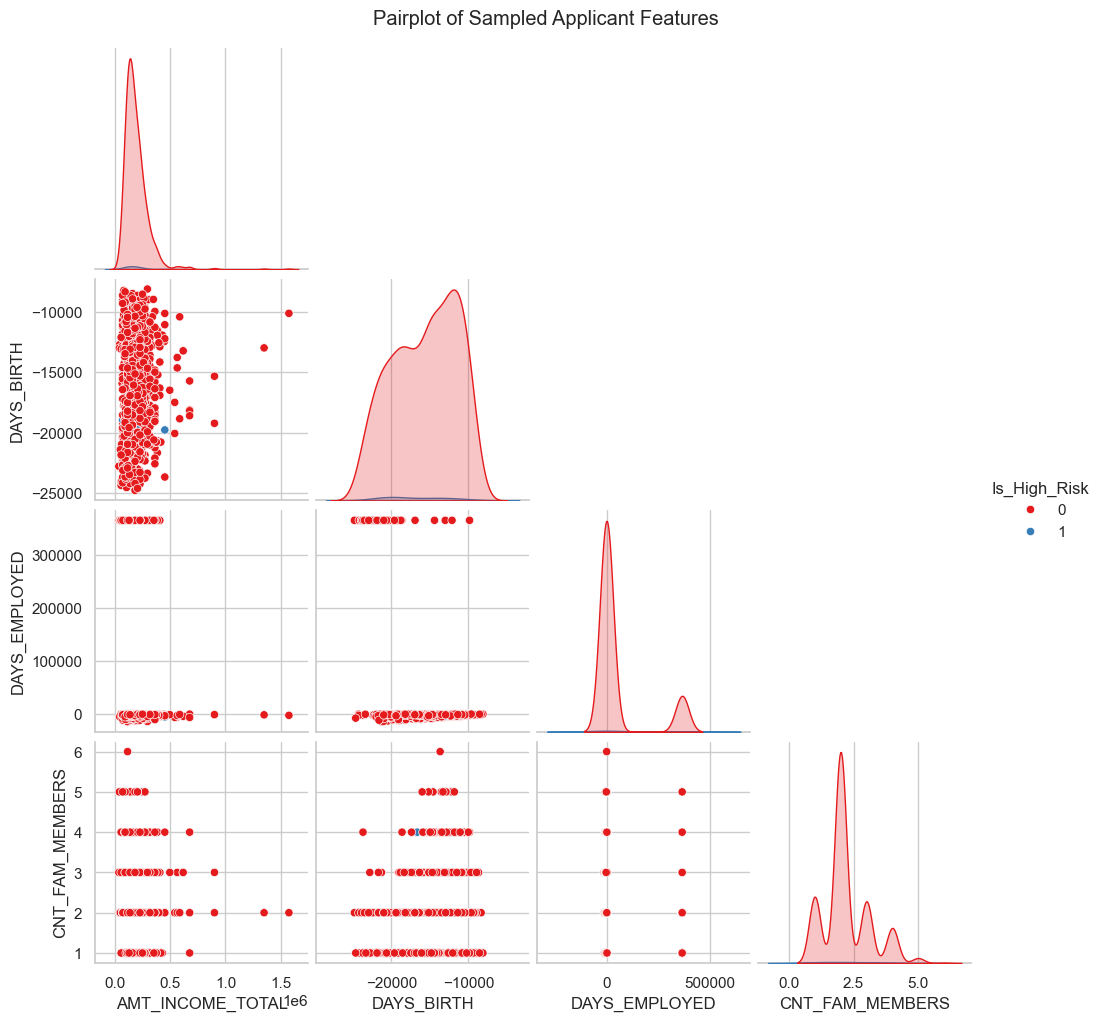


Starting Categorical Encoding...
Categorical Encoding Complete. Current shape of dataframe: (36457, 48)

Generating Correlation Heatmap...


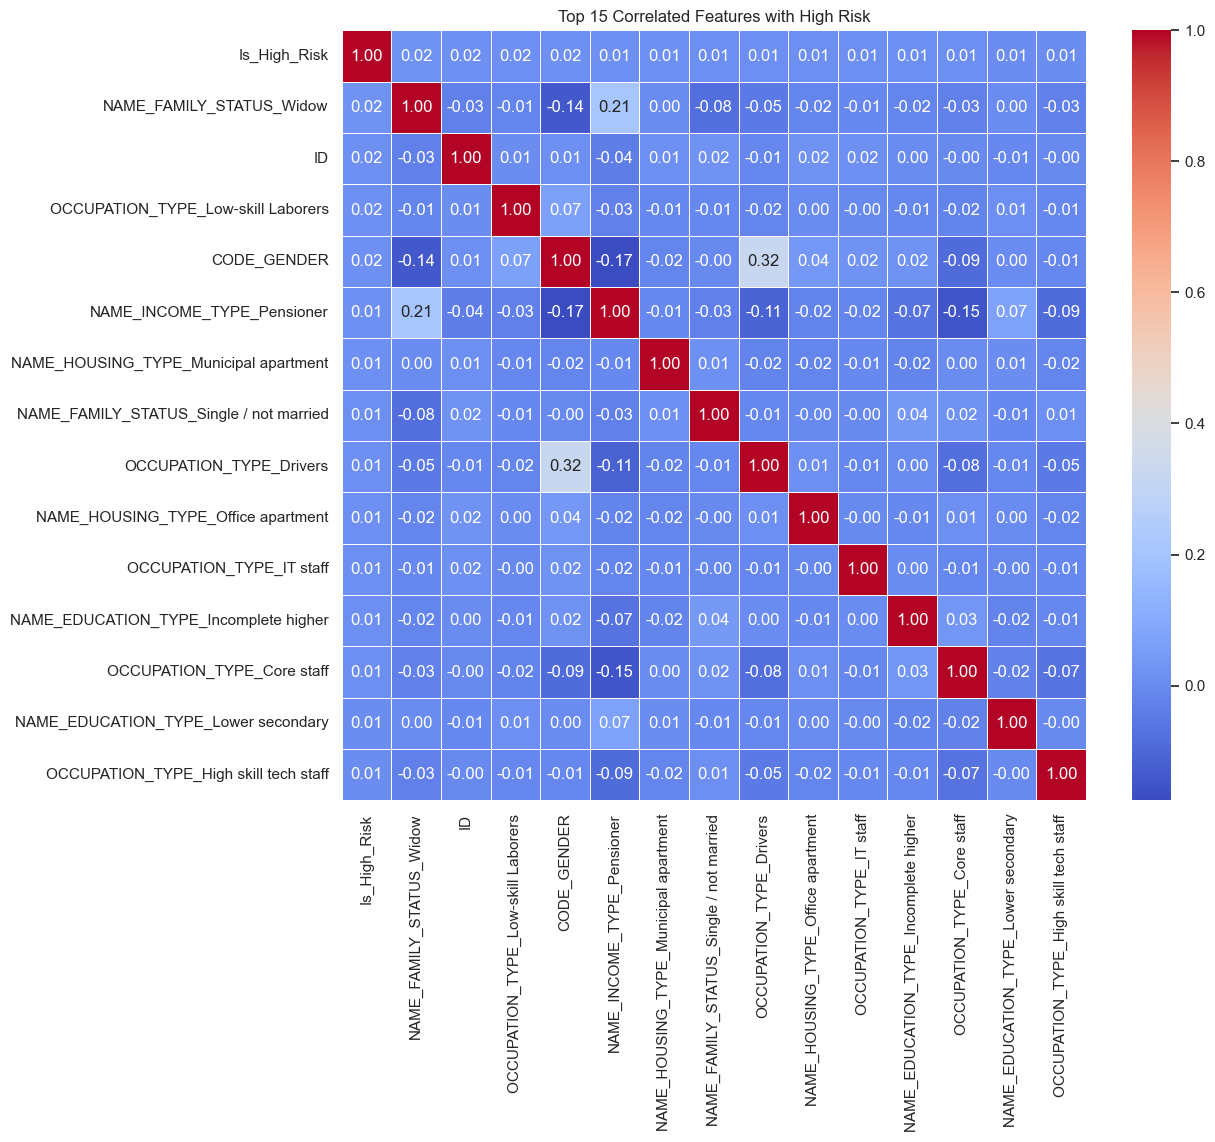

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# ==============================================================================
# Story 4 & 5: Bivariate Analysis and Categorical Encoding
# ==============================================================================

# --- 1. Bivariate Analysis: Pairplot (Pre-Encoding Numeric Look) ---
print("Generating Pairplot for sampled numeric features...")
columns_to_plot = ['AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_FAM_MEMBERS', 'Is_High_Risk'] 

# Ensure these columns actually exist in your merged df before running
existing_cols = [col for col in columns_to_plot if col in df.columns]

# Sample 1,000 rows to prevent infinite hanging
df_sample = df[existing_cols].sample(n=1000, random_state=42)

# Generate the pairplot
sns.pairplot(df_sample, hue='Is_High_Risk', corner=True, palette='Set1')
plt.suptitle('Pairplot of Sampled Applicant Features', y=1.02)
plt.show()

# --- 2. Categorical Encoding (Fulfilling Epic 3) ---
print("\nStarting Categorical Encoding...")

# Binary Label Encoding (Mapping 2-option categories to 0 and 1)
le = LabelEncoder()
binary_cols = ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']

for col in binary_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col])

# One-Hot Encoding (For categories with 3+ options)
multi_cols = ['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']
existing_multi_cols = [col for col in multi_cols if col in df.columns]

# IMPORTANT ADDITION: dtype=int forces 0/1 output instead of True/False
df = pd.get_dummies(df, columns=existing_multi_cols, drop_first=True, dtype=int)

print(f"Categorical Encoding Complete. Current shape of dataframe: {df.shape}")

# --- 3. Bivariate Analysis: Correlation Heatmap (Post-Encoding) ---
print("\nGenerating Correlation Heatmap...")
plt.figure(figsize=(12, 10)) 

# Calculate correlation matrix on all numeric columns
correlation_matrix = df.corr(numeric_only=True) 

# Get the top 15 features most correlated with Target Variable
k = 15 
cols = correlation_matrix.nlargest(k, 'Is_High_Risk')['Is_High_Risk'].index

# THE FIX: We bypass NumPy entirely and use Pandas to subset the matrix
cm = correlation_matrix.loc[cols, cols]

# Plot the heatmap
sns.heatmap(cm, annot=True, cmap='coolwarm', fmt='.2f', 
            yticklabels=cols.values, xticklabels=cols.values, linewidths=.5)
plt.title('Top 15 Correlated Features with High Risk')
plt.show()

In [5]:
import pandas as pd
from IPython.display import display

# Story 5: Descriptive Statistics (Post-Encoding)

print("--- Continuous Numerical Data Summary ---")
# We drop the binary columns and target to focus purely on continuous variables like Income and Age
continuous_cols = [col for col in df.columns if df[col].nunique() > 2]
num_summary = df[continuous_cols].describe().T.round(3)
display(num_summary)


print("\n--- Categorical / Binary Feature Summary ---")
# Since we already one-hot encoded, we look for columns with exactly two unique values (0 and 1)
# This naturally includes our target 'Is_High_Risk'
binary_cols = [col for col in df.columns if df[col].nunique() == 2]

if len(binary_cols) > 0:
    # Calculating the mean of a 0/1 column gives us the proportion of '1's!
    binary_summary = pd.DataFrame({
        'Total Count': df[binary_cols].count(),
        'Proportion (Mean)': df[binary_cols].mean().round(3)
    })
    
    # Sort by proportion to easily see the most common traits
    display(binary_summary.sort_values(by='Proportion (Mean)', ascending=False))
else:
    print("No binary columns found.")

--- Continuous Numerical Data Summary ---


,count,mean,std,min,25%,50%,75%,max
ID,36457.0,5078226.997,41875.241,5008804.0,5042028.0,5074614.0,5115396.0,5150487.0
CNT_CHILDREN,36457.0,0.430,0.742,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,36457.0,186685.737,101789.226,27000.0,121500.0,157500.0,225000.0,1575000.0
DAYS_BIRTH,36457.0,-15975.173,4200.550,-25152.0,-19438.0,-15563.0,-12462.0,-7489.0
DAYS_EMPLOYED,36457.0,59262.936,137651.335,-15713.0,-3153.0,-1552.0,-408.0,365243.0
CNT_FAM_MEMBERS,36457.0,2.198,0.912,1.0,2.0,2.0,3.0,20.0



--- Categorical / Binary Feature Summary ---


,Total Count,Proportion (Mean)
NAME_HOUSING_TYPE_House / apartment,36457,0.893
NAME_FAMILY_STATUS_Married,36457,0.687
NAME_EDUCATION_TYPE_Secondary / secondary special,36457,0.680
FLAG_OWN_REALTY,36457,0.672
NAME_INCOME_TYPE_Working,36457,0.516
FLAG_OWN_CAR,36457,0.380
CODE_GENDER,36457,0.330
FLAG_PHONE,36457,0.295
NAME_EDUCATION_TYPE_Higher education,36457,0.271
FLAG_WORK_PHONE,36457,0.226
